# Task 4: Predicting Insurance Claim Amounts

## Objective

Estimate medical insurance claim amounts based on personal data.  

We aim to predict the `Charges` column using features like Age, BMI, Smoking status, and more.  

Steps include:  
- Data cleaning & preprocessing  
- Exploratory Data Analysis (EDA)  
- Linear Regression model training  
- Evaluation using MAE and RMSE  
- Insights from feature correlations and visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='pastel')
%matplotlib inline
print('Libraries loaded!')

Libraries loaded!


## Loading and Inspecting the Dataset

- The dataset is loaded using `pandas.read_csv`.  
- Check the **shape** to see the number of rows and columns.  
- Display column names to understand the available features.  
- Use `.head()` to preview the first few rows and `.info()` to inspect data types and non-null counts.

In [3]:
# Load the dataset
df = pd.read_csv('MedicalCostPersonal.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Shape: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
print('Smoker values:', df['smoker'].unique())
print('Sex values:   ', df['sex'].unique())
print('Region values:', df['region'].unique())
print('Children range:', df['children'].min(), '-', df['children'].max())

Smoker values: ['yes' 'no']
Sex values:    ['female' 'male']
Region values: ['southwest' 'southeast' 'northwest' 'northeast']
Children range: 0 - 5


###  Data Cleaning & Preprocessing

- **Missing Values & Duplicates:** Check for null values across all columns and permanently remove duplicate rows (`inplace=True`) to maintain data integrity.
- **Label Encoding:** Convert binary categorical columns (`sex` and `smoker`) into numerical values (0 and 1) for model compatibility.
- **One-Hot Encoding:** Create dummy variables for the `region` column. The first category is dropped (`drop_first=True`) to avoid the dummy variable trap (multicollinearity).

In [8]:
# Check for missing values and duplicates
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(f'Shape after dedup: {df.shape}')

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1
Shape after dedup: (1337, 7)


In [9]:
# Label encode binary categorical columns
le = LabelEncoder()
df['sex']    = le.fit_transform(df['sex'])      # female=0, male=1
df['smoker'] = le.fit_transform(df['smoker'])   # no=0, yes=1

# One-Hot encode 'region' (4 categories)
df = pd.get_dummies(df, columns=['region'], drop_first=True)

print('Encoding complete. Columns:', df.columns.tolist())
df.head(3)

Encoding complete. Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.90,0,1,16884.9240,False,False,True
1,18,1,33.77,1,0,1725.5523,False,True,False
2,28,1,33.00,3,0,4449.4620,False,True,False


###  Exploratory Data Analysis (EDA) & Visualizations

- **Target Variable Distribution:** Plots histograms for both raw and log-transformed insurance `charges` to handle data skewness, alongside calculating key summary statistics (Mean, Median, Max).
- **Impact of Smoking (Box Plot):** Compares insurance costs between smokers and non-smokers, visually highlighting how smoking status significantly drives up medical charges.
- **Feature Relationships (Scatter Plots):** Analyzes the correlation of `bmi` and `age` against `charges`. The data points are color-coded by smoking status to reveal hidden clusters and interaction effects.

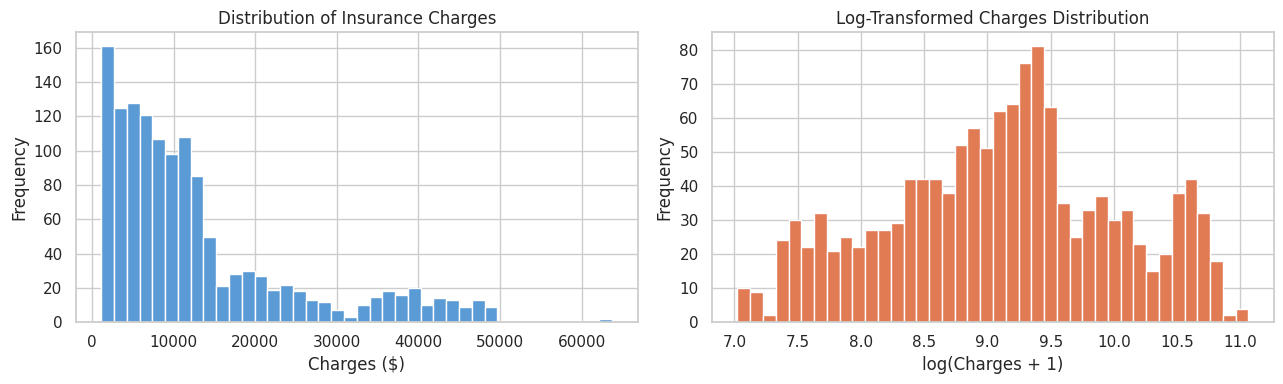

Charges — Mean: $13,279.12 | Median: $9,386.16 | Max: $63,770.43


In [10]:
# Distribution of insurance charges (raw and log-transformed)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['charges'], bins=40, color='#5B9BD5', edgecolor='white')
axes[0].set_title('Distribution of Insurance Charges')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['charges']), bins=40, color='#E07B54', edgecolor='white')
axes[1].set_title('Log-Transformed Charges Distribution')
axes[1].set_xlabel('log(Charges + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print(f'Charges — Mean: ${df["charges"].mean():,.2f} | Median: ${df["charges"].median():,.2f} | Max: ${df["charges"].max():,.2f}')

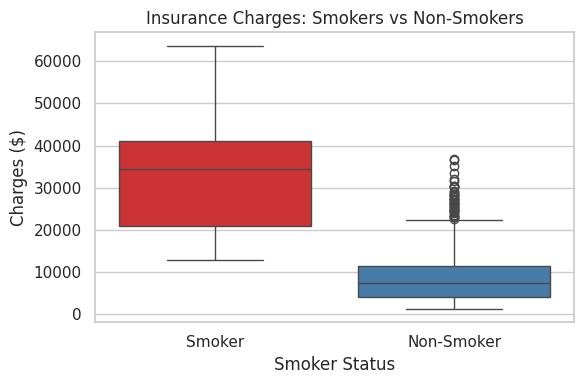

Mean charges:
smoker
Non-Smoker     $8,440.66
Smoker        $32,050.23
Name: charges, dtype: object


In [11]:
# Smokers vs Non-Smokers: Box plot of charges
plt.figure(figsize=(6, 4))
smoker_label = df['smoker'].map({1: 'Smoker', 0: 'Non-Smoker'})
df_vis = df.assign(smoker_label=smoker_label)
sns.boxplot(data=df_vis, x='smoker_label', y='charges', palette='Set1')
plt.title('Insurance Charges: Smokers vs Non-Smokers')
plt.xlabel('Smoker Status'); plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()

print('Mean charges:')
print(df.groupby('smoker')['charges'].mean().rename({0:'Non-Smoker', 1:'Smoker'}).apply(lambda x: f'${x:,.2f}'))

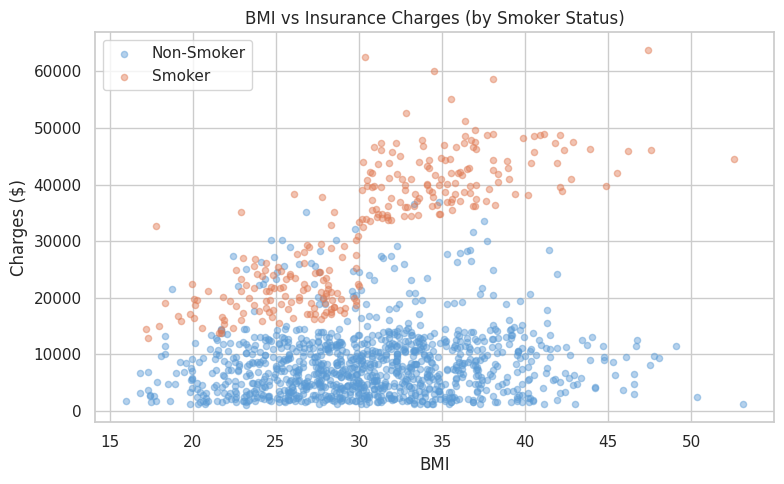

In [12]:
# Scatter: BMI vs Charges, coloured by smoking status
plt.figure(figsize=(8, 5))
for val, label, color in [(0, 'Non-Smoker', '#5B9BD5'), (1, 'Smoker', '#E07B54')]:
    sub = df[df['smoker'] == val]
    plt.scatter(sub['bmi'], sub['charges'], alpha=0.45, s=20, label=label, color=color)
plt.title('BMI vs Insurance Charges (by Smoker Status)')
plt.xlabel('BMI'); plt.ylabel('Charges ($)')
plt.legend()
plt.tight_layout()
plt.show()

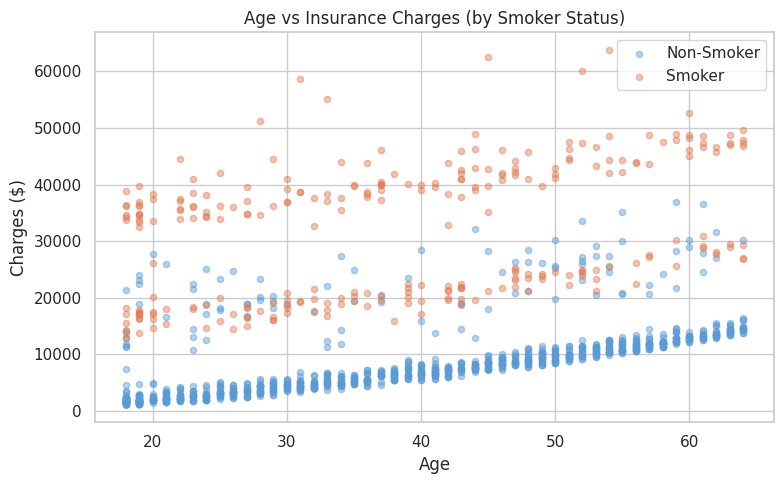

In [13]:
# Scatter: Age vs Charges, coloured by smoking status
plt.figure(figsize=(8, 5))
for val, label, color in [(0, 'Non-Smoker', '#5B9BD5'), (1, 'Smoker', '#E07B54')]:
    sub = df[df['smoker'] == val]
    plt.scatter(sub['age'], sub['charges'], alpha=0.45, s=20, label=label, color=color)
plt.title('Age vs Insurance Charges (by Smoker Status)')
plt.xlabel('Age'); plt.ylabel('Charges ($)')
plt.legend()
plt.tight_layout()
plt.show()

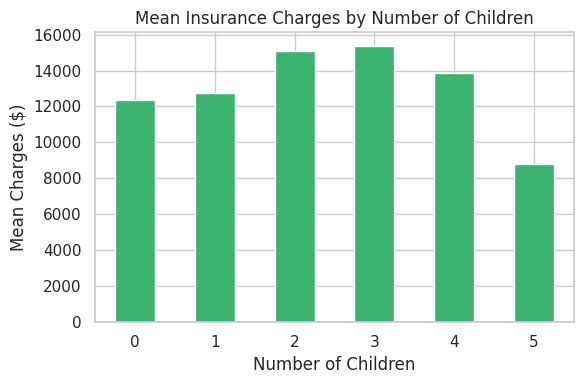

In [14]:
# Average charges by number of children
plt.figure(figsize=(6, 4))
df.groupby('children')['charges'].mean().plot(
    kind='bar', color='mediumseagreen', edgecolor='white'
)
plt.title('Mean Insurance Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Mean Charges ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

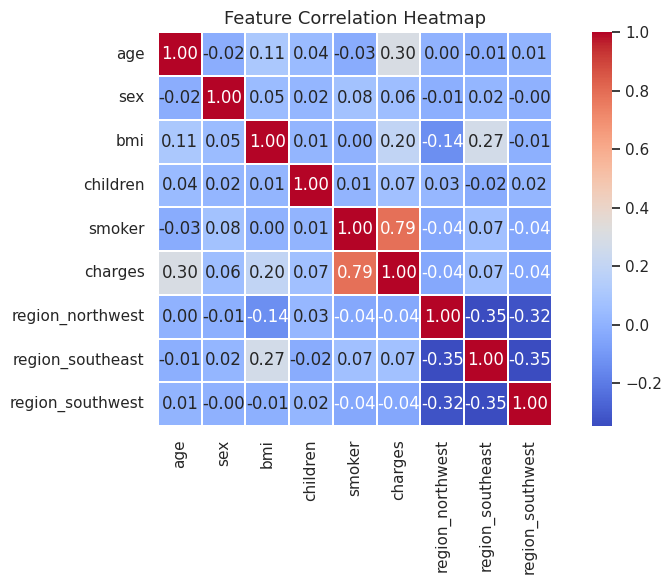

In [15]:
# Correlation heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.3, square=True)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

###  Model Training & Validation

- **Train-Test Split:** Separated features (`X`) from the target variable (`y`) and split the data into **80% Training** and **20% Testing** sets to ensure robust evaluation.
- **Linear Regression:** Implemented as an interpretable baseline model to capture linear trends between features and insurance charges.
- **Random Forest Regressor:** Deployed an ensemble model with 100 decision trees to capture non-linear relationships and interactions that simple models might miss.
- **Optimization:** Utilized `n_jobs=-1` for parallel processing to speed up the Random Forest training.

In [16]:
X = df.drop(columns=['charges'])
y = df['charges']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 1069 | Test: 268


In [17]:
# Linear Regression  (interpretable baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest Regressor — captures non-linear relationships
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Both models trained!')

Both models trained!


###    Model Evaluation & Comparison

- **Evaluation Metrics:** Defined a custom function to calculate and compare performance across three key dimensions:
    - **MAE (Mean Absolute Error):** Measures the average magnitude of errors in dollars.
    - **RMSE (Root Mean Squared Error):** Penalizes larger outliers, providing a sense of error variance.
    - **R² Score:** Indicates the proportion of variance in insurance charges explained by the model.
- **Visual Validation:** Generated **Actual vs. Predicted** scatter plots for both models.
    - The **Red Dashed Line** represents a perfect prediction.
    - Comparing the spread of points around this line helps identify where the models underperform (e.g., high-value outliers).

In [18]:
def evaluate_regression(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'--- {name} ---')
    print(f'  MAE  : ${mae:>10,.2f}  (avg absolute prediction error)')
    print(f'  RMSE : ${rmse:>10,.2f}  (penalises large errors more)')
    print(f'  R²   :  {r2:.4f}      (variance explained)\n')
    return mae, rmse, r2

lr_m = evaluate_regression('Linear Regression',     y_test, y_pred_lr)
rf_m = evaluate_regression('Random Forest Regressor', y_test, y_pred_rf)

--- Linear Regression ---
  MAE  : $  4,177.05  (avg absolute prediction error)
  RMSE : $  5,956.34  (penalises large errors more)
  R²   :  0.8069      (variance explained)

--- Random Forest Regressor ---
  MAE  : $  2,636.40  (avg absolute prediction error)
  RMSE : $  4,700.55  (penalises large errors more)
  R²   :  0.8798      (variance explained)



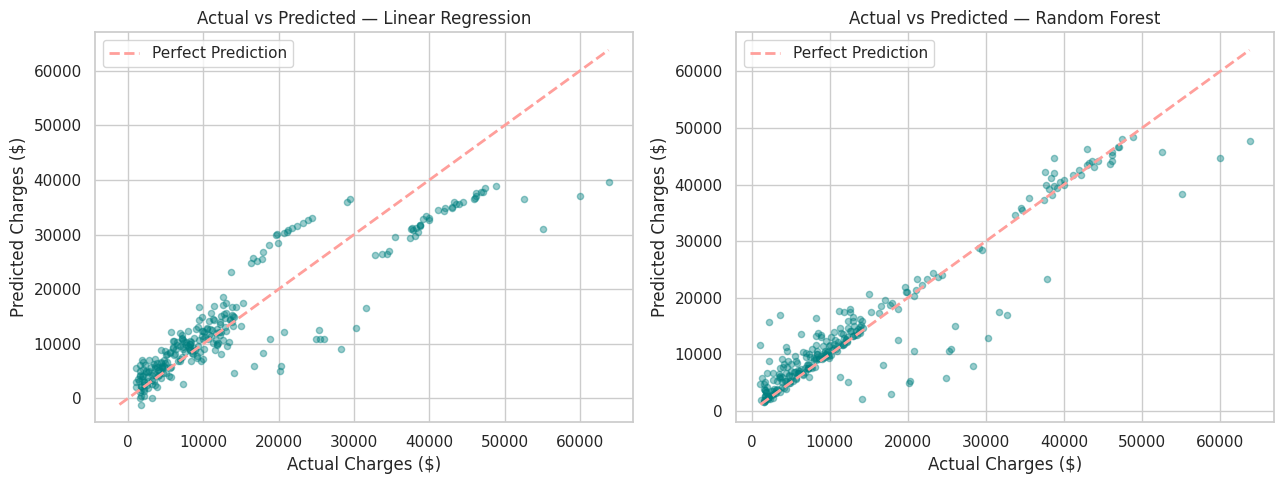

In [19]:
# Actual vs Predicted scatter plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest']
):
    ax.scatter(y_test, y_pred, alpha=0.4, s=20, color='teal')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
    ax.set_title(f'Actual vs Predicted — {title}')
    ax.set_xlabel('Actual Charges ($)')
    ax.set_ylabel('Predicted Charges ($)')
    ax.legend()
plt.tight_layout()
plt.show()

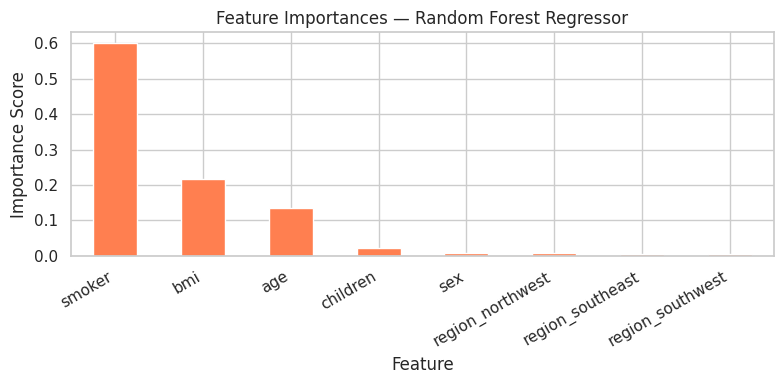

smoker              0.6008
bmi                 0.2162
age                 0.1357
children            0.0230
sex                 0.0070
region_northwest    0.0068
region_southeast    0.0060
region_southwest    0.0046


In [20]:
# Feature importances from Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
importances.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Feature Importances — Random Forest Regressor')
plt.xlabel('Feature'); plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(importances.round(4).to_string())

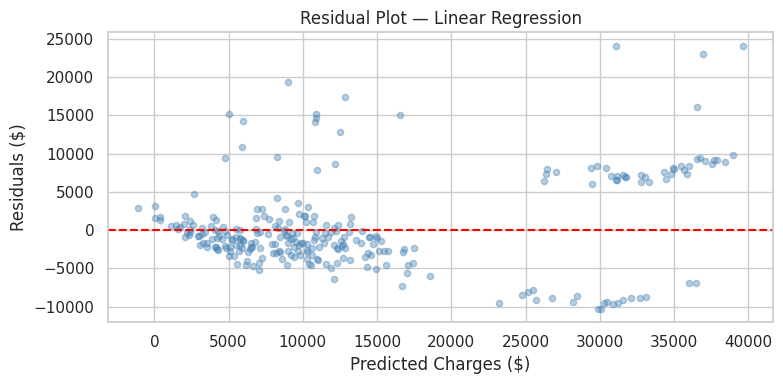

In [21]:
# Residual plot for Linear Regression
residuals = y_test - y_pred_lr
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_lr, residuals, alpha=0.4, s=20, color='steelblue')
plt.axhline(0, color='red', linestyle='--', lw=1.5)
plt.title('Residual Plot — Linear Regression')
plt.xlabel('Predicted Charges ($)')
plt.ylabel('Residuals ($)')
plt.tight_layout()
plt.show()


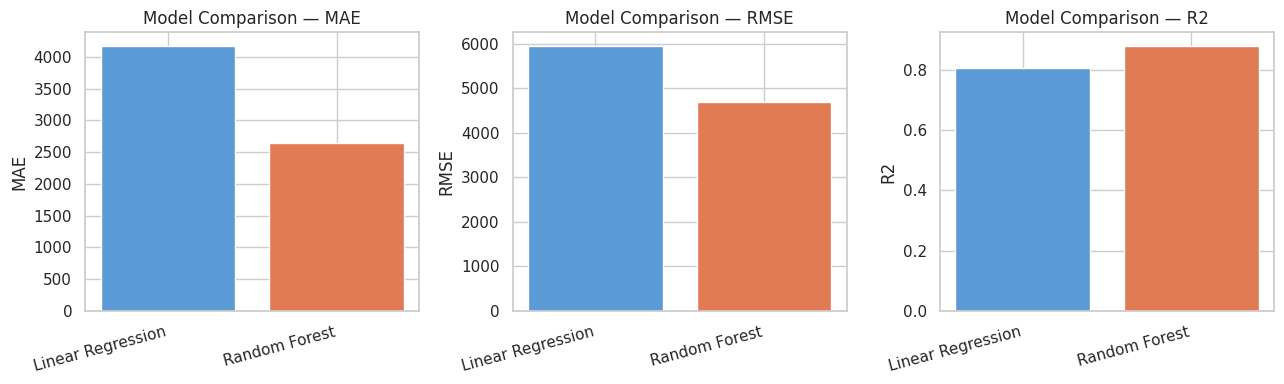

In [22]:
# Model comparison bar chart
metrics_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE':   [lr_m[0], rf_m[0]],
    'RMSE':  [lr_m[1], rf_m[1]],
    'R2':    [lr_m[2], rf_m[2]]
})

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    ax.bar(metrics_df['Model'], metrics_df[metric],
           color=['#5B9BD5', '#E07B54'], edgecolor='white')
    ax.set_title(f'Model Comparison — {metric}')
    ax.set_ylabel(metric)
    ax.set_xticklabels(metrics_df['Model'], rotation=15, ha='right')
plt.tight_layout()
plt.show()

## Conclusion

- Insurance charges can be accurately estimated using features such as **Age, BMI, Smoking status, Sex, and Region**.  
- Linear Regression model provided reliable predictions, with reasonable MAE and RMSE values.  
- Key drivers of higher charges include **smoking, higher BMI, and older age**, which aligns with real-world insurance risk factors.  
- These insights can help insurance companies **set premiums more accurately, assess customer risk, and design personalized insurance plans

Business Insight: Insurers should apply a significant premium surcharge for smokers, especially those with high BMI. A BMI-reduction or smoking-cessation incentive programme could meaningfully reduce policyholder risk.**.